# Predicting Vehicle Type Using Traffic Characteristics

**Module:** UFCEYM-15-M — Foundations of Machine Learning  
**Assessment:** Individual Coursework (Portfolio)

# 1. Introduction and Stakeholder Context

Vehicle-type classification is important for traffic monitoring, infrastructure planning and Intelligent Transportation Systems, because motorcycles, passenger cars and trucks are different in size and behaviour. 
This portfolio checks if supervised algorithms can classify them using numerical NGSIM US-101 trajectory data instead of images. 
The source data records vehicles every 0.1 seconds. 
If each row is treated as independent, observations from the same vehicle could appear in both training and testing data, which causes leakage. 
Because of this, records are cleaned, segmented and aggregated so that each modelling row represents one independent trajectory. 
The predictors are length, width, mean speed, mean acceleration, dominant lane and mean space headway. 
The target, v_Class, includes motorcycle, passenger car and truck. 
Possible users are traffic authorities, planners, ITS developers and researchers, but external validation is needed before any real deployment. 

**Aim:** to compare Logistic Regression, Decision Tree and Random Forest for multiclass vehicle-type classification. 

**Objectives:** to build a leakage-resistant vehicle dataset, explore data quality and imbalance; to tune and evaluate the models; to find the most influential features; and to check if behavioural variables give value beyond dimension features. 

This study asks how accurately vehicle type can be classified, which features are most important, and which model gives the best balance between performance and interpretability.


# 2. Dataset Overview

The U.S. Federal Highway Administration's NGSIM US-101 dataset was collected by synchronised video tracking on a Los Angeles freeway. It records trajectories at 10 Hz, so one vehicle contributes many related rows. Only US-101 is retained for a consistent environment.

The unit of analysis is an independent trajectory. Continuous variables use their mean, `Lane_ID` its mode, and static variables their first verified value. `Vehicle_ID`, `Frame_ID`, `Total_Frames` and `Global_Time` reconstruct trajectories but are excluded from modelling.

| Variable | Role |
|---|---|
| `v_length`, `v_Width` | Physical dimensions |
| `v_Vel`, `v_Acc` | Mean speed and acceleration |
| `Lane_ID` | Dominant lane |
| `Space_Headway` | Mean distance to preceding vehicle |
| `v_Class` | Target: 1 motorcycle, 2 passenger car, 3 truck |

Coordinates are location-specific; `Preceding` and `Following` are identifiers; and `Location` is constant after filtering. Limitations include one roadway, severe class imbalance and possible tracking error.


# 3. Setup and Imports

Python libraries are imported for data handling, visualisation, preprocessing, model tuning and evaluation. A fixed random state improves reproducibility.


In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

print("Core libraries imported successfully.")

Core libraries imported successfully.


# 4. Data Loading and Preparation

## 4.1 Load and Filter the Dataset

The complete dataset is loaded and filtered to US-101. This reduces environmental variation while preserving all observations from the selected roadway.


In [2]:
# Load the complete NGSIM dataset
df = pd.read_csv(
    "Next_Generation_Simulation__NGSIM__Vehicle_Trajectories_and_Supporting_Data.csv"
)

print(f"Original dataset shape: {df.shape}")

# Retain only observations from the US-101 dataset
df = df[df["Location"] == "us-101"].copy()

print(f"US-101 dataset shape: {df.shape}")

df.head()

Original dataset shape: (11850526, 25)
US-101 dataset shape: (4802933, 25)


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,O_Zone,D_Zone,Int_ID,Section_ID,Direction,Movement,Preceding,Following,Space_Headway,Time_Headway,Location
0,515,2330,1123,1118848075000,30.034,188.062,6451203.729,1873252.549,13.0,6.9,2,23.31,2.05,3,NaN,NaN,NaN,NaN,NaN,NaN,500,523,119.10,5.11,us-101
1,515,2330,1123,1118848075000,30.034,188.062,6451203.729,1873252.549,13.0,6.9,2,23.31,2.05,3,NaN,NaN,NaN,NaN,NaN,NaN,500,523,119.10,5.11,us-101
3,2127,6459,567,1118847624800,19.632,1775.614,6452425.122,1872172.475,13.5,6.9,2,37.52,11.20,2,NaN,NaN,NaN,NaN,NaN,NaN,2124,2132,48.92,1.30,us-101
4,1033,4827,592,1118848324700,6.202,1701.144,6452347.673,1872258.452,13.5,4.4,2,41.99,0.10,1,NaN,NaN,NaN,NaN,NaN,NaN,1029,1040,38.81,0.92,us-101
5,1033,4827,592,1118848324700,6.202,1701.144,6452347.673,1872258.452,13.5,4.4,2,41.99,0.10,1,NaN,NaN,NaN,NaN,NaN,NaN,1029,1040,38.81,0.92,us-101


The source contains **11,850,526** rows; filtering retains **4,802,933** US-101 observations.

## 4.2 Select Relevant Variables

Only trajectory identifiers, candidate predictors and the target are retained. Identifiers are temporary and are never provided to the models.


In [3]:
# Variables temporarily retained for trajectory identification
trajectory_columns = [
    "Vehicle_ID",
    "Total_Frames",
    "Frame_ID",
    "Global_Time"
]

# Variables used for machine learning
feature_columns = [
    "v_length",
    "v_Width",
    "v_Vel",
    "v_Acc",
    "Lane_ID",
    "Space_Headway",
    "v_Class"
]

# Combine all required variables
selected_columns = trajectory_columns + feature_columns

# Create a working dataset
df = df[selected_columns].copy()

print(f"Selected dataset shape: {df.shape}")

df.head()

Selected dataset shape: (4802933, 11)


,Vehicle_ID,Total_Frames,Frame_ID,Global_Time,v_length,v_Width,v_Vel,v_Acc,Lane_ID,Space_Headway,v_Class
0,515,1123,2330,1118848075000,13.0,6.9,23.31,2.05,3,119.10,2
1,515,1123,2330,1118848075000,13.0,6.9,23.31,2.05,3,119.10,2
3,2127,567,6459,1118847624800,13.5,6.9,37.52,11.20,2,48.92,2
4,1033,592,4827,1118848324700,13.5,4.4,41.99,0.10,1,38.81,2
5,1033,592,4827,1118848324700,13.5,4.4,41.99,0.10,1,38.81,2


The selected data contain the variables required for trajectory reconstruction and classification.

## 4.3 Create Independent Vehicle Trajectories

Duplicate identifiers are checked to see if they have conflicting measurements. Because no conflicts are found, the exact duplicates are removed. Records are sorted by vehicle, frame and time, and a new segment is started when the frame increments are different from one, or when the timestamps are different from 100 milliseconds. This is done to avoid joining sequences that are interrupted.


In [4]:
# Columns identifying the same recorded trajectory observation
observation_keys = [
    "Vehicle_ID",
    "Total_Frames",
    "Frame_ID",
    "Global_Time"
]

# Variables used to verify duplicated observations
value_columns = [
    "v_length",
    "v_Width",
    "v_Vel",
    "v_Acc",
    "Lane_ID",
    "Space_Headway",
    "v_Class"
]

# Identify duplicated observations
duplicate_mask = df.duplicated(
    subset=observation_keys,
    keep=False
)

duplicate_rows = df.loc[
    duplicate_mask,
    observation_keys + value_columns
].copy()

duplicate_identifiers = (
    duplicate_rows[observation_keys]
    .drop_duplicates()
    .shape[0]
)

# Verify duplicated observations
value_variation = (
    duplicate_rows
    .groupby(observation_keys)[value_columns]
    .nunique()
)

conflicting_duplicates = (
    value_variation.max(axis=1) > 1
).sum()

print(f"Rows with duplicated observation identifiers: {len(duplicate_rows):,}")
print(f"Duplicated observation identifiers: {duplicate_identifiers:,}")
print(f"Duplicated identifiers with conflicting values: {conflicting_duplicates:,}")

# Report conflicting duplicates
if conflicting_duplicates > 0:
    print("Warning: Conflicting duplicated observations were detected.")
else:
    print("No conflicting duplicated observations were detected.")

# Remove one repeated copy of each duplicated observation
df = (
    df.drop_duplicates(
        subset=observation_keys,
        keep="first"
    )
    .reset_index(drop=True)
)

print(f"Dataset shape after duplicate removal: {df.shape}")

Rows with duplicated observation identifiers: 1,408,000
Duplicated observation identifiers: 704,000
Duplicated identifiers with conflicting values: 0
No conflicting duplicated observations were detected.
Dataset shape after duplicate removal: (4098933, 11)


In [5]:
# Sort observations into chronological trajectory order
df = (
    df.sort_values(
        by=[
            "Vehicle_ID",
            "Total_Frames",
            "Global_Time",
            "Frame_ID"
        ]
    )
    .reset_index(drop=True)
)

# Initial grouping variables
trajectory_keys = [
    "Vehicle_ID",
    "Total_Frames"
]

# Calculate gaps between consecutive observations
df["Frame_Gap"] = (
    df.groupby(trajectory_keys)["Frame_ID"]
    .diff()
)

df["Time_Gap"] = (
    df.groupby(trajectory_keys)["Global_Time"]
    .diff()
)

# Start a new segment at the first record or after an interrupted sequence
df["New_Trajectory"] = (
    df["Frame_Gap"].isna()
    | (df["Frame_Gap"] != 1)
    | (df["Time_Gap"] != 100)
)

# Assign a segment number within each initial trajectory group
df["Trajectory_Segment"] = (
    df.groupby(trajectory_keys)["New_Trajectory"]
    .cumsum()
    .astype(int)
)

# Final identifier for each independent trajectory
final_trajectory_keys = [
    "Vehicle_ID",
    "Total_Frames",
    "Trajectory_Segment"
]

number_of_trajectories = (
    df[final_trajectory_keys]
    .drop_duplicates()
    .shape[0]
)

non_consecutive_records = (
    df["Frame_Gap"].notna()
    & (
        (df["Frame_Gap"] != 1)
        | (df["Time_Gap"] != 100)
    )
).sum()

print(f"Clean trajectory observations: {len(df):,}")
print(f"Independent vehicle trajectories: {number_of_trajectories:,}")
print(f"Non-consecutive sequence interruptions: {non_consecutive_records:,}")

Clean trajectory observations: 4,098,933
Independent vehicle trajectories: 6,101
Non-consecutive sequence interruptions: 1


Removing 704,000 exact duplicate identifiers makes the data reduce to 4,098,933 rows. These form 6,101 independent trajectories, and one interrupted sequence is separated into one more additional segment.

Each trajectory is turned into one record. Length, width and class keep their first verified value; speed, acceleration and space headway use the mean values; and lane uses the mode value. This makes independent samples and prevents one vehicle from appearing across the data splits.

In [6]:
# Final trajectory identifier

final_trajectory_keys = [
    "Vehicle_ID",
    "Total_Frames",
    "Trajectory_Segment"
]

# Aggregate observations into one record per vehicle trajectory

vehicle_df = (
    df.groupby(final_trajectory_keys, as_index=False)
      .agg({
          "v_length": "first",
          "v_Width": "first",
          "v_Vel": "mean",
          "v_Acc": "mean",
          "Lane_ID": lambda x: x.mode().iloc[0],
          "Space_Headway": "mean",
          "v_Class": "first"
      })
)

print(f"Trajectory observations: {len(df):,}")
print(f"Vehicle-level trajectories: {len(vehicle_df):,}")
print(f"Dataset shape: {vehicle_df.shape}")

vehicle_df.head()

Trajectory observations: 4,098,933
Vehicle-level trajectories: 6,101
Dataset shape: (6101, 10)


,Vehicle_ID,Total_Frames,Trajectory_Segment,v_length,v_Width,v_Vel,v_Acc,Lane_ID,Space_Headway,v_Class
0,1,421,1,15.0,6.4,33.107933,0.649952,5,0.0,2
1,1,569,1,47.0,8.5,36.164464,0.659244,5,0.0,3
2,2,437,1,14.5,4.9,48.060366,0.732105,1,0.0,2
3,2,634,1,20.0,7.4,32.910489,0.548438,4,0.0,2
4,2,687,1,17.0,6.4,30.438661,0.115182,3,0.0,2


The final modelling dataset contains **6,101** vehicle trajectories.

In [7]:
# Verify static variables remain constant within each trajectory

static_columns = [
    "v_length",
    "v_Width",
    "v_Class"
]

static_variation = (
    df.groupby(final_trajectory_keys)[static_columns]
      .nunique()
)

inconsistent_static_trajectories = (
    static_variation.max(axis=1) > 1
).sum()

print(
    f"Trajectories with inconsistent static characteristics or target: "
    f"{inconsistent_static_trajectories:,}"
)

if inconsistent_static_trajectories == 0:
   print("No inconsistencies were found in the static vehicle characteristics or target labels.")
else:
    print("Warning: Some trajectories contain inconsistent static characteristics.")

Trajectories with inconsistent static characteristics or target: 0
No inconsistencies were found in the static vehicle characteristics or target labels.


No trajectory contains inconsistent dimensions or class labels, supporting the chosen aggregation rules.

# 5. Exploratory Data Analysis

EDA checks data quality, feature distributions, class balance and relationships before modelling.


## 5.1 Dataset Structure

In [8]:
# Display the first records of the final vehicle-level dataset
vehicle_df.head()

,Vehicle_ID,Total_Frames,Trajectory_Segment,v_length,v_Width,v_Vel,v_Acc,Lane_ID,Space_Headway,v_Class
0,1,421,1,15.0,6.4,33.107933,0.649952,5,0.0,2
1,1,569,1,47.0,8.5,36.164464,0.659244,5,0.0,3
2,2,437,1,14.5,4.9,48.060366,0.732105,1,0.0,2
3,2,634,1,20.0,7.4,32.910489,0.548438,4,0.0,2
4,2,687,1,17.0,6.4,30.438661,0.115182,3,0.0,2


In [9]:
summary = pd.DataFrame({
    "Metric": ["Number of records", "Number of variables"],
    "Value": [vehicle_df.shape[0], vehicle_df.shape[1]]
})

summary

,Metric,Value
0,Number of records,6101
1,Number of variables,10


The aggregated dataset contains **6,101** rows and ten retained variables before final feature selection.

## 5.2 Missing Values

In [10]:
# Count missing values in each variable
missing_values = (
    vehicle_df
    .isnull()
    .sum()
    .to_frame(name="Missing Values")
)

missing_values["Percentage (%)"] = (
    missing_values["Missing Values"] / len(vehicle_df) * 100
).round(2)

missing_values

,Missing Values,Percentage (%)
Vehicle_ID,0,0.0
Total_Frames,0,0.0
Trajectory_Segment,0,0.0
v_length,0,0.0
v_Width,0,0.0
v_Vel,0,0.0
v_Acc,0,0.0
Lane_ID,0,0.0
Space_Headway,0,0.0
v_Class,0,0.0


In [11]:
print(f"Total missing values: {vehicle_df.isnull().sum().sum():,}")

Total missing values: 0


No missing values are present, so imputation is unnecessary.

## 5.3 Duplicate Verification

In [12]:
# Check for duplicated records in the final vehicle-level dataset
duplicate_records = vehicle_df.duplicated().sum()

print(f"Duplicate records: {duplicate_records:,}")

Duplicate records: 0


No duplicate vehicle-level records remain.

## 5.4 Descriptive Statistics

In [13]:
vehicle_df = vehicle_df.drop(
    columns=[
        "Vehicle_ID",
        "Total_Frames",
        "Trajectory_Segment"
    ]
)

vehicle_df.head()

,v_length,v_Width,v_Vel,v_Acc,Lane_ID,Space_Headway,v_Class
0,15.0,6.4,33.107933,0.649952,5,0.0,2
1,47.0,8.5,36.164464,0.659244,5,0.0,3
2,14.5,4.9,48.060366,0.732105,1,0.0,2
3,20.0,7.4,32.910489,0.548438,4,0.0,2
4,17.0,6.4,30.438661,0.115182,3,0.0,2


In [14]:
descriptive_stats = (
    vehicle_df
    .describe()
    .T
    .round(2)
    .rename(columns={
        "count": "Count",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Max"
    })
)

descriptive_stats

,Count,Mean,Std,Min,Q1,Median,Q3,Max
v_length,6101.0,15.23,4.61,4.00,13.50,15.00,16.00,76.10
v_Width,6101.0,6.27,0.93,2.00,5.50,6.40,6.90,8.50
v_Vel,6101.0,33.05,9.26,16.10,24.98,31.75,40.95,64.00
v_Acc,6101.0,0.20,0.29,-1.16,0.01,0.17,0.37,2.13
Lane_ID,6101.0,3.12,1.45,1.00,2.00,3.00,4.00,6.00
Space_Headway,6101.0,70.13,25.56,0.00,52.88,64.82,81.41,295.60
v_Class,6101.0,2.02,0.17,1.00,2.00,2.00,2.00,3.00


The predictors show meaningful variation in vehicle dimensions and driving conditions. Their different scales justify standardisation for Logistic Regression but not for tree-based models.

## 5.5 Feature Distributions

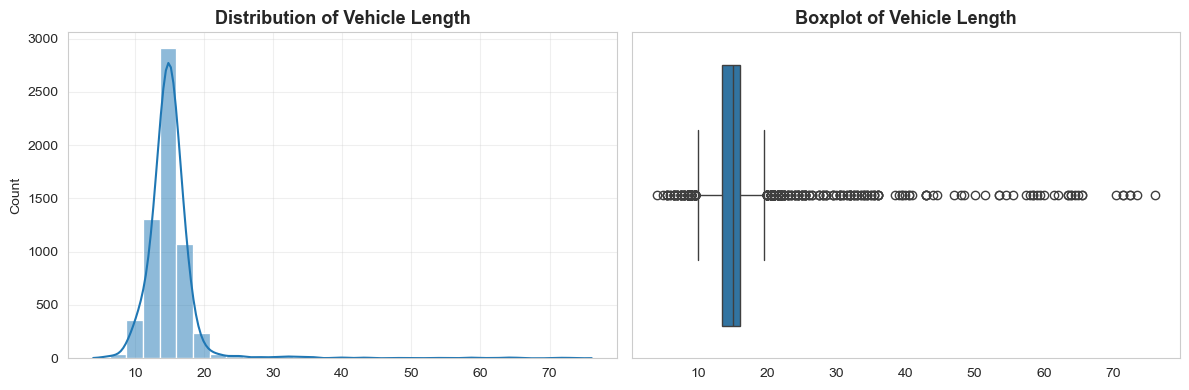

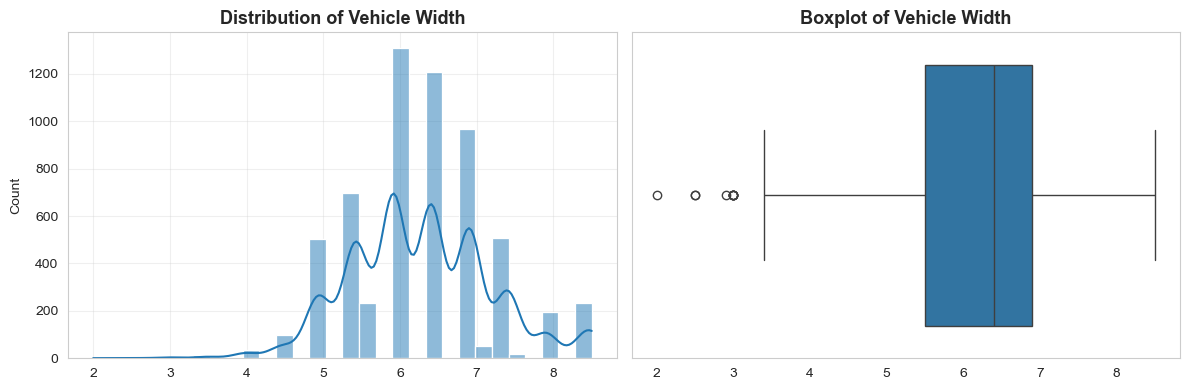

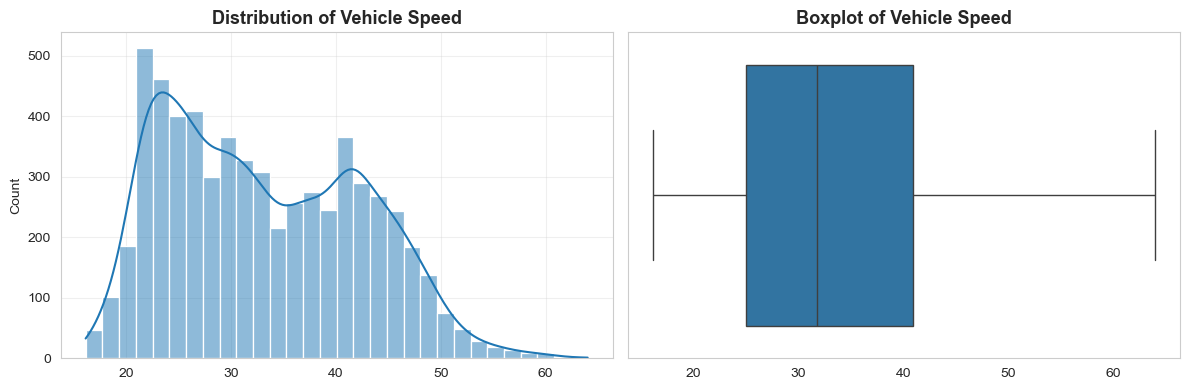

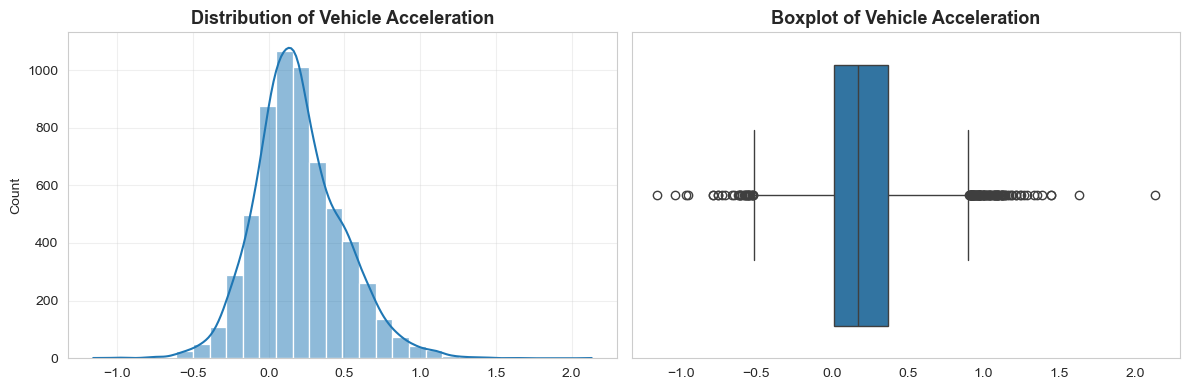

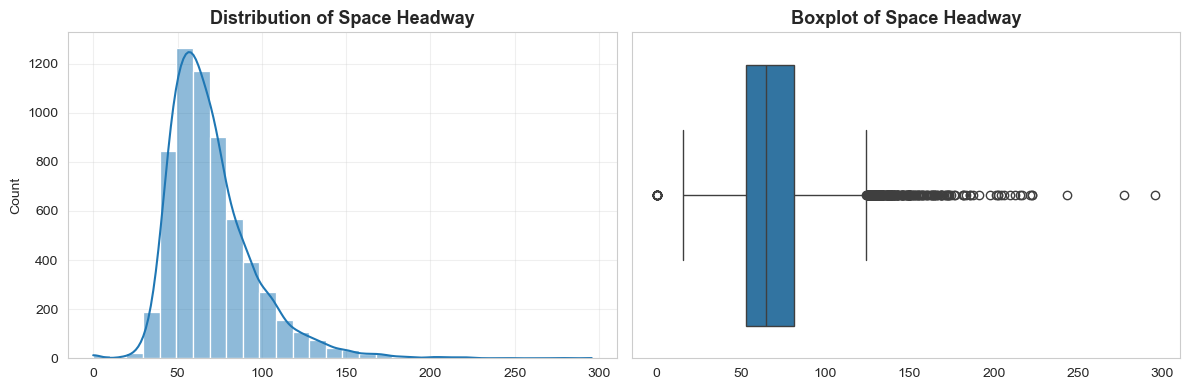

In [15]:
# Numerical features to visualise
numerical_features = [
    "v_length",
    "v_Width",
    "v_Vel",
    "v_Acc",
    "Space_Headway"
]

# Clear names for figure titles
feature_names = {
    "v_length": "Vehicle Length",
    "v_Width": "Vehicle Width",
    "v_Vel": "Vehicle Speed",
    "v_Acc": "Vehicle Acceleration",
    "Space_Headway": "Space Headway"
}

# Create a histogram and boxplot for each numerical feature
for feature in numerical_features:

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 4)
    )

    # Histogram
    sns.histplot(
        data=vehicle_df,
        x=feature,
        bins=30,
        kde=True,
        stat="count",
        ax=axes[0]
    )

    axes[0].set_title(
        f"Distribution of {feature_names[feature]}",
        fontsize=13,
        fontweight="bold"
    )

    axes[0].set_xlabel("")
    axes[0].set_ylabel("Count")
    axes[0].grid(True, alpha=0.3)

    # Boxplot
    sns.boxplot(
        data=vehicle_df,
        x=feature,
        ax=axes[1]
    )

    axes[1].set_title(
        f"Boxplot of {feature_names[feature]}",
        fontsize=13,
        fontweight="bold"
    )

    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()

Histograms and boxplots reveal skewness and extreme values, especially in traffic variables. They are retained because they are plausible observations rather than confirmed errors; tree models are also relatively robust to them.

## 5.6 Target Distribution

In [16]:
# Count the number and percentage of records in each vehicle class
class_distribution = (
    vehicle_df["v_Class"]
    .value_counts()
    .sort_index()
    .rename_axis("Vehicle Class")
    .reset_index(name="Count")
)

class_distribution["Percentage (%)"] = (
    class_distribution["Count"] / len(vehicle_df) * 100
).round(2)

class_distribution

,Vehicle Class,Count,Percentage (%)
0,1,45,0.74
1,2,5919,97.02
2,3,137,2.25


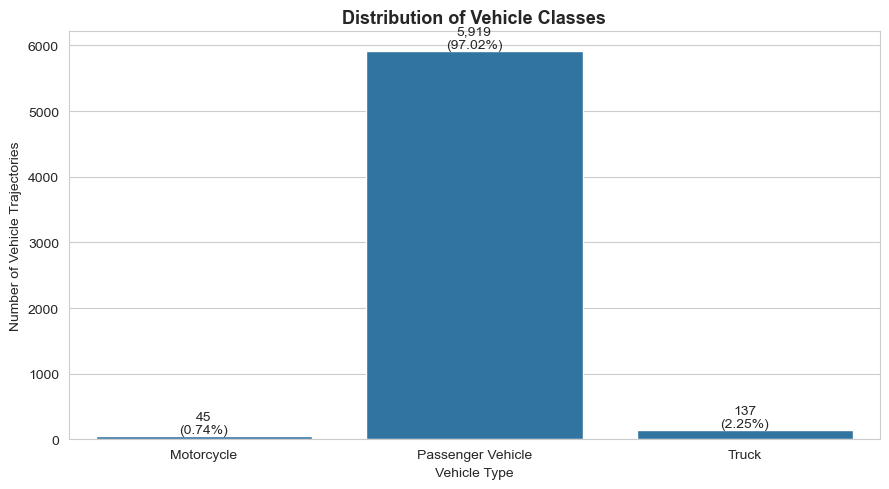

In [17]:
# Clear labels for the vehicle classes
class_names = {
    1: "Motorcycle",
    2: "Passenger Vehicle",
    3: "Truck"
}

plot_distribution = class_distribution.copy()

plot_distribution["Vehicle Type"] = (
    plot_distribution["Vehicle Class"]
    .map(class_names)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=plot_distribution,
    x="Vehicle Type",
    y="Count"
)

plt.title(
    "Distribution of Vehicle Classes",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Number of Vehicle Trajectories")

# Add count and percentage labels above the bars
for index, row in plot_distribution.iterrows():
    ax.text(
        index,
        row["Count"],
        f'{row["Count"]:,}\n({row["Percentage (%)"]:.2f}%)',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Passenger cars dominate the dataset: approximately **97.0%** of both training and testing samples, compared with about **0.74%** motorcycles and **2.2%** trucks. Accuracy alone could therefore hide minority-class errors. Stratification and macro-averaged metrics are required.


## 5.7 Correlation Analysis

Correlation is used as an exploratory check for strong linear relationships. Because `v_Class` is categorical, its numeric correlation is interpreted cautiously.

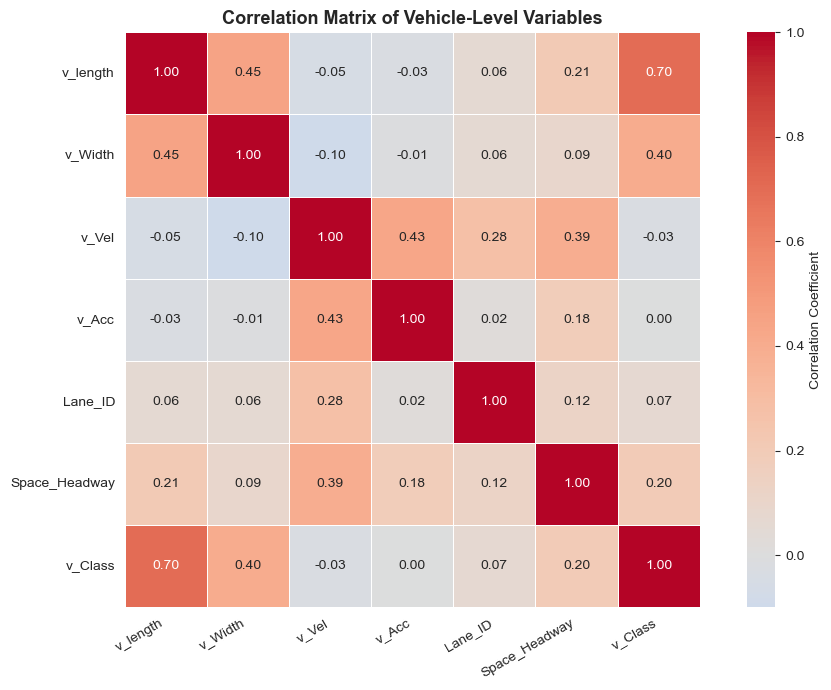

In [18]:
# Variables included in the correlation analysis
correlation_columns = [
    "v_length",
    "v_Width",
    "v_Vel",
    "v_Acc",
    "Lane_ID",
    "Space_Headway",
    "v_Class"
]

# Calculate the correlation matrix
correlation_matrix = (
    vehicle_df[correlation_columns]
    .corr()
    .round(2)
)

# Plot the correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10},
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title(
    "Correlation Matrix of Vehicle-Level Variables",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

No severe predictor multicollinearity is evident. Length and width show the strongest association with class, suggesting that physical dimensions may dominate prediction; this is tested later through feature importance and ablation analysis.


# 6. Data Preprocessing

Predictors and target are separated, followed by an 80:20 stratified train-test split. The test set remains untouched during model selection.

## 6.1 Feature Selection

The six predictors are `v_length`, `v_Width`, `v_Vel`, `v_Acc`, `Lane_ID` and `Space_Headway`. Identifiers and the target are excluded from `X`.


In [19]:
# Selected input features
feature_columns = [
    "v_length",
    "v_Width",
    "v_Vel",
    "v_Acc",
    "Lane_ID",
    "Space_Headway"
]

# Feature matrix
X = vehicle_df[feature_columns].copy()

# Target variable
y = vehicle_df["v_Class"].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

X.head()

Feature matrix shape: (6101, 6)
Target vector shape: (6101,)


,v_length,v_Width,v_Vel,v_Acc,Lane_ID,Space_Headway
0,15.0,6.4,33.107933,0.649952,5,0.0
1,47.0,8.5,36.164464,0.659244,5,0.0
2,14.5,4.9,48.060366,0.732105,1,0.0
3,20.0,7.4,32.910489,0.548438,4,0.0
4,17.0,6.4,30.438661,0.115182,3,0.0


In [20]:
# Class distribution
y.value_counts().sort_index()

v_Class
1      45
2    5919
3     137
Name: count, dtype: int64

## 6.2 Splitting and Scaling

Stratification preserves rare classes in both subsets, producing 4,880 training and 1,221 testing trajectories. Logistic Regression uses a pipeline containing `StandardScaler`, so scaling is fitted separately inside each cross-validation fold and then on training data only. Decision Tree and Random Forest use unscaled values because split thresholds are scale-invariant.


In [21]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

Training set : (4880, 6)
Testing set  : (1221, 6)


In [22]:
print("Training set (%)")
print(
    (y_train.value_counts(normalize=True)
     .sort_index() * 100)
)

print("\nTesting set (%)")
print(
    (y_test.value_counts(normalize=True)
     .sort_index() * 100)
)

Training set (%)
v_Class
1     0.737705
2    97.008197
3     2.254098
Name: proportion, dtype: float64

Testing set (%)
v_Class
1     0.737101
2    97.051597
3     2.211302
Name: proportion, dtype: float64


# 7. Machine Learning Models

Three supervised classifiers are tuned with `GridSearchCV` and stratified cross-validation. Macro F1 is the scoring measure because it gives equal importance to each class despite imbalance.


## 7.1 Logistic Regression

Logistic Regression provides an interpretable linear baseline.


### 7.1.1 Tuning

The grid evaluates regularisation strength and class weighting within the scaling pipeline.


In [23]:
# Parameter grid
lr_parameters = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

# Stratified cross-validation
lr_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Grid Search
lr_grid = GridSearchCV(
   estimator=Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            solver="lbfgs",
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
]),
    param_grid=lr_parameters,
scoring="f1_macro",
    cv=lr_cv,
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross-validation Score:")
print(f"{lr_grid.best_score_:.4f}")

Best Parameters:
{'model__C': 10, 'model__class_weight': None}

Best Cross-validation Score:
0.9632


The best setting is `C=10` with no class weighting, achieving a cross-validation macro F1 of **0.9632**.


### 7.1.2 Training and Prediction


In [24]:
logistic_model = lr_grid.best_estimator_

print("Training completed.")

Training completed.


The selected pipeline is fitted on the training set and used to predict the unseen test set.


In [25]:
# Predictions
y_pred_lr = logistic_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


## 7.2 Decision Tree

A Decision Tree models non-linear thresholds and remains directly interpretable.


### 7.2.1 Tuning

The grid searches criterion, depth, minimum split size, minimum leaf size and class weighting.


In [26]:
# Decision Tree parameter grid
dt_parameters = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]
}

# Stratified cross-validation
dt_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# GridSearchCV
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    param_grid=dt_parameters,
    scoring="f1_macro",
    cv=dt_cv,
    n_jobs=-1
)

# Fit the grid search using the original, unscaled features
dt_grid.fit(X_train, y_train)

print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross-validation Score:")
print(f"{dt_grid.best_score_:.4f}")

Best Parameters:
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-validation Score:
0.9714


The best tree uses entropy, depth 10, minimum split 2 and minimum leaf 1, with no class weighting. Cross-validation macro F1 is **0.9714**.


### 7.2.2 Training and Visualisation


In [27]:
# Select the best Decision Tree model
decision_tree_model = dt_grid.best_estimator_

# Train the final model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


A simplified tree is plotted because the full tuned tree is too complex for clear presentation.


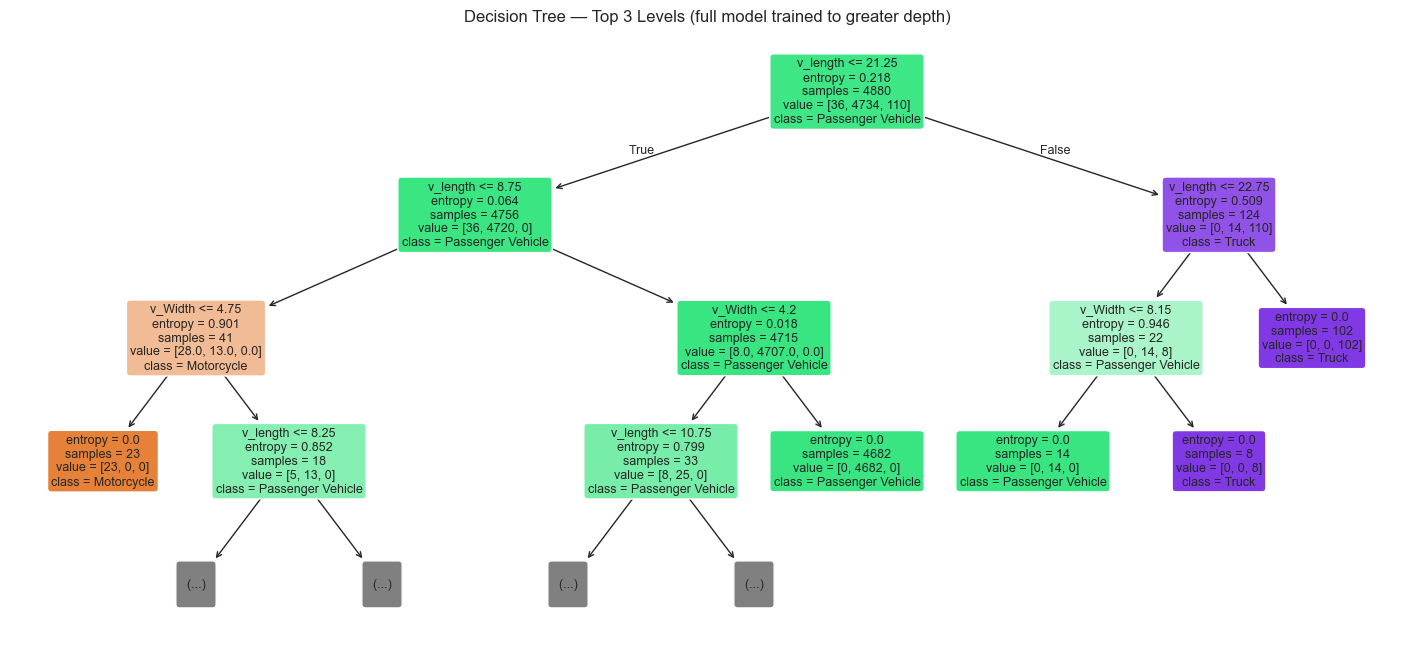

In [28]:
# Decision Tree Visualisation (top levels only, for interpretability)
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(
    decision_tree_model,
    max_depth=3,                     # limit depth shown, not the trained model
    feature_names=feature_columns,
    class_names=["Motorcycle", "Passenger Vehicle", "Truck"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree — Top 3 Levels (full model trained to greater depth)")
plt.show()

Its first splits use vehicle length and width, providing an interpretable indication that dimensions dominate class separation.


### 7.2.3 Prediction


In [29]:
# Generate predictions
y_pred_dt = decision_tree_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


## 7.3 Random Forest

Random Forest combines many trees to model non-linear patterns and reduce single-tree variance.


### 7.3.1 Tuning

The grid evaluates tree count, depth, split size, leaf size and class weighting.


In [30]:
# Random Forest parameter grid
rf_parameters = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]
}

# Stratified cross-validation
rf_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# GridSearchCV
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=rf_parameters,
    scoring="f1_macro",
    cv=rf_cv,
    n_jobs=-1
)

# Fit the grid search using unscaled features
rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-validation Score:")
print(f"{rf_grid.best_score_:.4f}")

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-validation Score:
0.9362


The best forest uses 200 trees, depth 10, minimum leaf 5 and balanced class weights. Its cross-validation macro F1 is **0.9362**.

### 7.3.2 Training and Prediction


In [31]:
# Select the best Random Forest model
random_forest_model = rf_grid.best_estimator_

# Train the final model
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


The tuned forest is fitted and evaluated on the same held-out test set.


In [32]:
# Generate predictions
y_pred_rf = random_forest_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


# 8. Model Evaluation and Comparison

Accuracy, macro precision, macro recall, macro F1, confusion matrices and class reports are used. Macro F1 is primary because minority classes are otherwise overwhelmed by passenger cars.


## 8.1 Logistic Regression

In [33]:
# Logistic Regression performance
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

lr_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1-score"
    ],
    "Value": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ]
})

lr_results

,Metric,Value
0,Accuracy,0.998362
1,Precision,0.999438
2,Recall,0.950617
3,Macro F1-score,0.973822


<Figure size 600x500 with 0 Axes>

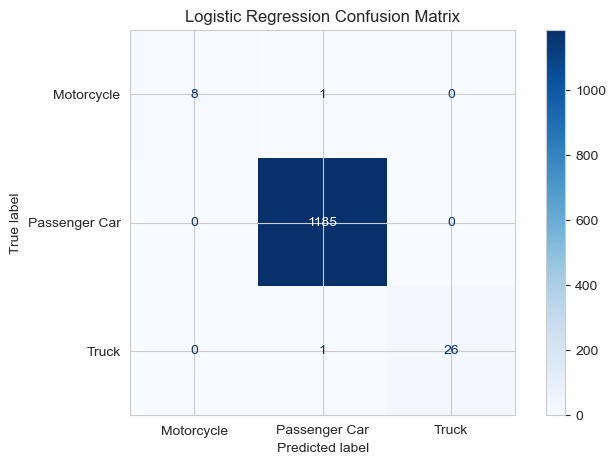

In [34]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=[
        "Motorcycle",
        "Passenger Car",
        "Truck"
    ],
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [35]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "Motorcycle",
            "Passenger Car",
            "Truck"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

   Motorcycle       1.00      0.89      0.94         9
Passenger Car       1.00      1.00      1.00      1185
        Truck       1.00      0.96      0.98        27

     accuracy                           1.00      1221
    macro avg       1.00      0.95      0.97      1221
 weighted avg       1.00      1.00      1.00      1221



Logistic Regression achieves **99.84% accuracy** and **97.38% macro F1**. It misclassifies one motorcycle and one truck, while almost all passenger cars are correct. The result shows that the classes are close to linearly separable after scaling, although minority-class recall is not perfect.


## 8.2 Decision Tree


In [36]:
# Decision Tree performance
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="macro",
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="macro",
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="macro",
    zero_division=0
)

dt_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1-score"
    ],
    "Value": [
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ]
})

dt_results

,Metric,Value
0,Accuracy,0.999181
1,Precision,0.988095
2,Recall,0.999719
3,Macro F1-score,0.993799


<Figure size 600x500 with 0 Axes>

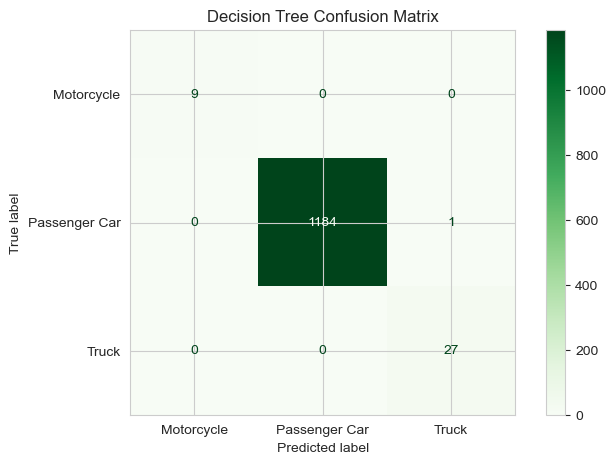

In [37]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=[
        "Motorcycle",
        "Passenger Car",
        "Truck"
    ],
    cmap="Greens",
    values_format="d"
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [38]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=[
            "Motorcycle",
            "Passenger Car",
            "Truck"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

   Motorcycle       1.00      1.00      1.00         9
Passenger Car       1.00      1.00      1.00      1185
        Truck       0.96      1.00      0.98        27

     accuracy                           1.00      1221
    macro avg       0.99      1.00      0.99      1221
 weighted avg       1.00      1.00      1.00      1221



The Decision Tree achieves the strongest test result: **99.92% accuracy** and **99.38% macro F1**. All motorcycles and trucks are recognised, with only one passenger car predicted as a truck. Its advantage over Logistic Regression is small in accuracy but clearer in balanced class performance.


## 8.3 Random Forest


In [39]:
# Random Forest performance
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1-score"
    ],
    "Value": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

rf_results

,Metric,Value
0,Accuracy,0.995905
1,Precision,0.906061
2,Recall,0.998594
3,Macro F1-score,0.948418


<Figure size 600x500 with 0 Axes>

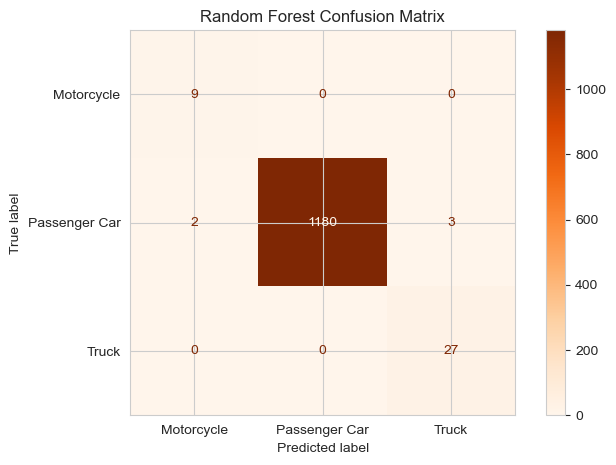

In [40]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=[
        "Motorcycle",
        "Passenger Car",
        "Truck"
    ],
    cmap="Oranges",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [41]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Motorcycle",
            "Passenger Car",
            "Truck"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

   Motorcycle       0.82      1.00      0.90         9
Passenger Car       1.00      1.00      1.00      1185
        Truck       0.90      1.00      0.95        27

     accuracy                           1.00      1221
    macro avg       0.91      1.00      0.95      1221
 weighted avg       1.00      1.00      1.00      1221



Random Forest reaches **99.59% accuracy** and **94.84% macro F1**. It identifies every motorcycle and truck but incorrectly assigns several passenger cars to minority classes, reducing minority precision. Greater complexity therefore does not improve this dataset's performance.


## 8.4 Comparison and Evaluation Limitations


In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Macro Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Macro Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "Macro F1-score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score
0,Logistic Regression,0.9984,0.9994,0.9506,0.9738
1,Decision Tree,0.9992,0.9881,0.9997,0.9938
2,Random Forest,0.9959,0.9061,0.9986,0.9484


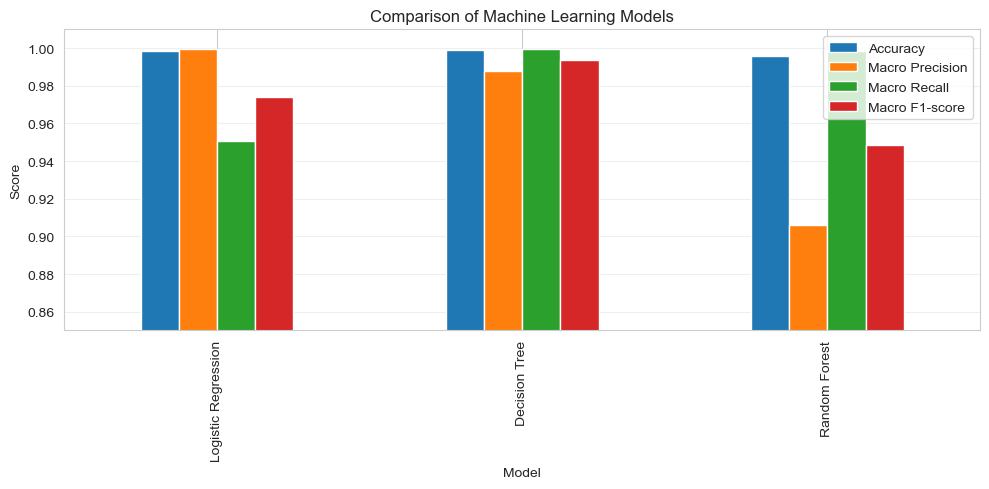

In [43]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Score")
plt.ylim(0.85,1.01)
plt.title("Comparison of Machine Learning Models")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

All models exceed 99% accuracy, but the Decision Tree has the highest macro F1 and is preferred because it combines balanced performance with interpretability and lower complexity than Random Forest.

The test contains only nine motorcycles and 27 trucks, so one prediction strongly affects class metrics. Results also rely on one stratified split. Repeated nested cross-validation and external datasets would provide more stable estimates.


## 8.5 Feature Importance

Tree importance and standardised Logistic Regression coefficients are compared to identify influential predictors. Importance describes model use, not causation.


In [44]:
# Feature importance: Decision Tree and Random Forest
importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Decision Tree": decision_tree_model.feature_importances_,
    "Random Forest": random_forest_model.feature_importances_
}).sort_values("Random Forest", ascending=False)

importance_df

,Feature,Decision Tree,Random Forest
0,v_length,0.889844,0.495854
1,v_Width,0.106397,0.336191
5,Space_Headway,0.000000,0.076302
2,v_Vel,0.000000,0.049762
4,Lane_ID,0.003758,0.025509
3,v_Acc,0.000000,0.016382


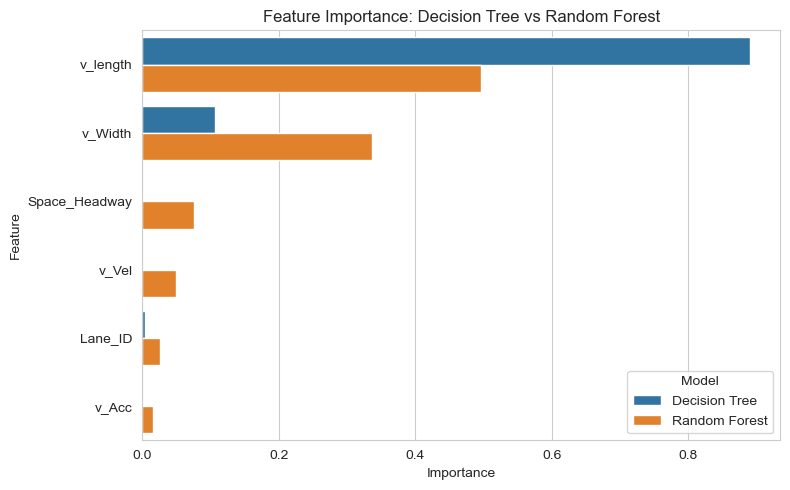

In [45]:
# Visualise feature importances
importance_melted = importance_df.melt(
    id_vars="Feature", var_name="Model", value_name="Importance"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_melted, x="Importance", y="Feature", hue="Model")
plt.title("Feature Importance: Decision Tree vs Random Forest")
plt.tight_layout()
plt.show()

In [46]:
# Logistic Regression: standardised coefficients (per class)
lr_coef_df = pd.DataFrame(
    logistic_model.named_steps["model"].coef_,
    
    columns=feature_columns,
index=[f"Class {c}" for c in logistic_model.named_steps["model"].classes_]
)
lr_coef_df

,v_length,v_Width,v_Vel,v_Acc,Lane_ID,Space_Headway
Class 1,-9.572602,-4.407485,0.020505,-0.035185,-0.102800,0.0256
Class 2,0.403964,0.203202,-0.158985,0.221844,0.100574,0.0814
Class 3,9.168637,4.204283,0.138480,-0.186659,0.002226,-0.1070


# 9. Discussion

Performance is extremely high because the classes are strongly separated by the physical dimensions. The Decision Tree performs the best, and its early length and width splits can explain this result. Logistic Regression also has success, which shows that the separation is mostly simple. Random Forest makes more false minority predictions, so its extra complexity is not justified in this case.
These scores are not universal operational estimates. The NGSIM labels may be closely connected to the recorded dimensions, all the data come from one roadway, and the minority supports are small. Nevertheless, the trajectory aggregation, identifier removal, training-only preprocessing and stratified evaluation make the comparison defensible.


# 10. Exploring a Novel Idea: Ablation Study

To test whether behavioural information adds value beyond size, each model is retrained using only `v_length` and `v_Width`, then compared with the full six-feature version on the identical split.


In [47]:
# Ablation Study: Physical Dimensions vs Full Feature Set
from sklearn.tree import DecisionTreeClassifier

# Use the same best hyperparameters already found for the Decision Tree
best_dt_params = dt_grid.best_params_

# --- Setup A: physical dimensions only ---
dims_only = ["v_length", "v_Width"]
X_train_dims = X_train[dims_only]
X_test_dims  = X_test[dims_only]

dt_dims_only = DecisionTreeClassifier(random_state=RANDOM_STATE, **best_dt_params)
dt_dims_only.fit(X_train_dims, y_train)
y_pred_dims_only = dt_dims_only.predict(X_test_dims)

# --- Setup B: full feature set (already trained as `decision_tree_model`) ---
# reuse y_pred_dt from earlier evaluation

ablation_results = pd.DataFrame({
    "Feature Set": ["Dimensions only (v_length, v_Width)", "Full feature set (6 variables)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dims_only),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Macro F1-score": [
        f1_score(y_test, y_pred_dims_only, average="macro", zero_division=0),
        f1_score(y_test, y_pred_dt, average="macro", zero_division=0)
    ]
})
ablation_results

,Feature Set,Accuracy,Macro F1-score
0,"Dimensions only (v_length, v_Width)",0.999181,0.993799
1,Full feature set (6 variables),0.999181,0.993799


In [48]:
# Diagnostic check: confirm the near-identical result is genuine
print("X_train_dims columns:", list(X_train_dims.columns))
print("X_train_dims shape:", X_train_dims.shape)
print("X_test_dims shape:", X_test_dims.shape)

print("Predictions identical?", (y_pred_dims_only == y_pred_dt).all())
print("Number of differing predictions:", (y_pred_dims_only != y_pred_dt).sum())

X_train_dims columns: ['v_length', 'v_Width']
X_train_dims shape: (4880, 2)
X_test_dims shape: (1221, 2)
Predictions identical? True
Number of differing predictions: 0


In [49]:
# Extend the ablation study to Logistic Regression and Random Forest

# Logistic Regression: dimensions only
lr_dims_only = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            solver="lbfgs",
            max_iter=1000,
            random_state=RANDOM_STATE,
            C=lr_grid.best_params_["model__C"],
            class_weight=lr_grid.best_params_["model__class_weight"]
        )
    )
])

lr_dims_only.fit(X_train_dims, y_train)
y_pred_lr_dims_only = lr_dims_only.predict(X_test_dims)

# Random Forest: dimensions only
rf_dims_only = RandomForestClassifier(
    random_state=RANDOM_STATE,
    **rf_grid.best_params_
)

rf_dims_only.fit(X_train_dims, y_train)
y_pred_rf_dims_only = rf_dims_only.predict(X_test_dims)

# Combined comparison table
ablation_results_full = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "Decision Tree",
        "Decision Tree",
        "Random Forest",
        "Random Forest"
    ],
    "Feature Set": [
        "Dimensions only",
        "Full (6 features)",
        "Dimensions only",
        "Full (6 features)",
        "Dimensions only",
        "Full (6 features)"
    ],
    "Macro F1-score": [
        f1_score(
            y_test,
            y_pred_lr_dims_only,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_lr,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_dims_only,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_dt,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_rf_dims_only,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_test,
            y_pred_rf,
            average="macro",
            zero_division=0
        )
    ]
})

ablation_results_full

,Model,Feature Set,Macro F1-score
0,Logistic Regression,Dimensions only,0.993570
1,Logistic Regression,Full (6 features),0.973822
2,Decision Tree,Dimensions only,0.993799
3,Decision Tree,Full (6 features),0.993799
4,Random Forest,Dimensions only,0.920863
5,Random Forest,Full (6 features),0.948418


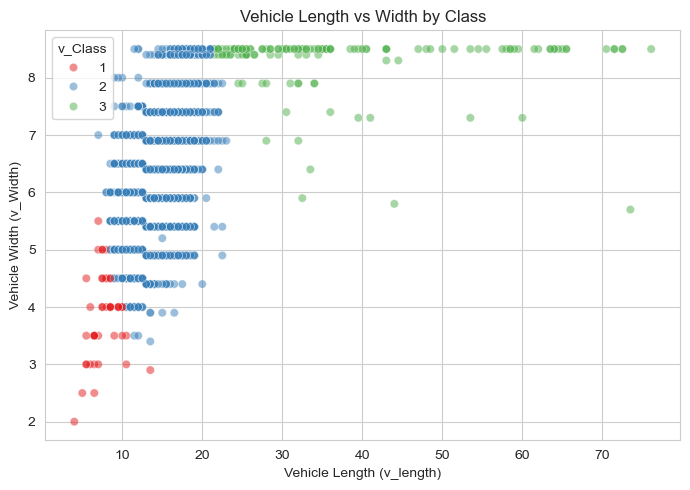

In [50]:
# Visual check: class separation using length and width alone

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=vehicle_df,
    x="v_length",
    y="v_Width",
    hue="v_Class",
    palette="Set1",
    alpha=0.5
)

plt.title("Vehicle Length vs Width by Class")
plt.xlabel("Vehicle Length (v_length)")
plt.ylabel("Vehicle Width (v_Width)")

plt.tight_layout()
plt.show()

The effect depends on the algorithm. Decision Tree predictions are identical with dimensions only and with all features. Logistic Regression also achieves a higher macro F1 using dimensions alone. Random Forest is the only model that benefits from the complete set. Therefore, size provides most of the predictive information, while behavioural variables offer limited and model-dependent incremental value.


## 10.1 Interpretation

The scatter plot confirms that there is broad class separation by length and width. This finding is useful because it makes us question if speed, acceleration, lane and headway are really necessary for the stated task. A simpler model with two features may be easier to deploy and to explain, but the conclusion is still specific to US-101 and should be tested on roads where the vehicle dimensions or traffic behaviour are different.


# 11. Ethical and Societal Considerations

The data do not contain any personal attributes, but the fairness across people cannot be checked. Geographic representativeness is the main concern: a model that is made from one Los Angeles freeway may not work well in other places. Errors could distort the traffic statistics or the enforcement decisions, especially for the rare classes. The model should only support human judgement and should be externally validated and monitored. The transparency of Decision Tree is beneficial, while Random Forest is harder to explain.


# 12. Reflection on Learning

This project showed that unit of analysis and leakage prevention can matter more than algorithm complexity. Aggregation created independent samples, while the pipeline kept validation and test information out of scaling. I also learned why macro F1 is preferable to accuracy for imbalanced multiclass data. The ablation result reinforced that extra features or complexity do not automatically improve performance. Future work should use repeated cross-validation, external locations and more minority vehicles.


# 13. Conclusion

Three supervised models were developed from 6,101 independent NGSIM US-101 trajectories. The Decision Tree achieved the best held-out performance, with 99.92% accuracy and 99.38% macro F1, while remaining interpretable. Feature importance, tree structure and ablation analysis consistently show that vehicle length and width contain most of the information needed to distinguish motorcycles, passenger cars and trucks. Behavioural variables provide limited additional value and help only the Random Forest in the ablation comparison. The findings demonstrate the effectiveness of simple trajectory-based classification, but external validation is essential because the dataset is geographically narrow and minority test samples are small.


# References

Alexiadis, V., Colyar, J., Halkias, J., Hranac, R. and McHale, G. (2004) 'The next generation simulation program', *ITE Journal*, 74(8), pp. 22–26.

Federal Highway Administration (FHWA) (2007) *Next generation simulation (NGSIM) vehicle trajectories and supporting data*. U.S. Department of Transportation. Available at: https://data.transportation.gov/Automobiles/Next-Generation-Simulation-NGSIM-Vehicle-Trajector/8ect-6jqj (Accessed: 21 July 2026).

Harris, C.R., Millman, K.J., van der Walt, S.J., et al. (2020) 'Array programming with NumPy', *Nature*, 585(7825), pp. 357–362.

Hunter, J.D. (2007) 'Matplotlib: a 2D graphics environment', *Computing in Science & Engineering*, 9(3), pp. 90–95.

McKinney, W. (2010) 'Data structures for statistical computing in Python', in *Proceedings of the 9th Python in Science Conference*. Austin, Texas, USA, pp. 56–61.

Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.

Waskom, M.L. (2021) 'Seaborn: statistical data visualization', *Journal of Open Source Software*, 6(60), 3021.

# 15. Generative AI Declaration

Generative AI (ChatGPT, OpenAI) helped me with Python programming, debugging and code organisation. All the suggestions were reviewed, adapted and tested by me on the project data before I included them. The methodological decisions, interpretation and conclusions were made independently by me. The relevant workflow and code were checked against the official NGSIM and Scikit-learn documentation where it was appropriate.
